# Analyse des résultats — évaluations RAGAS du prototype

Charge tous les runs disponibles dans `eval/results/` (un fichier `<label>.json` par run, produit par `evaluate_ragas.py --label <label>`). Aucun run n'en écrase un autre.

| Run | Système évalué |
|---|---|
| `baseline` | prototype d'origine (texte libre, client Mistral direct, aucune validation) |
| `validation_pydantic` | + couche de validation Pydantic complète : **entrée** (pipeline chunking/embedding et chunks récupérés validés) et **sortie** (`RAGAnswer` structurée, citations vérifiées, abstention possible). Prompt et température inchangés. |

**Structure** : chaque run est analysé indépendamment dans sa propre section (sections 1 et 2), avec exactement le même traitement. La comparaison entre runs est isolée en section 3, pour ne pas mélanger constat et évolution.

Chaque analyse de run couvre deux axes distincts :
- **qualité RAGAS** — 4 métriques jugées par gpt-4o ;
- **comportement d'abstention** — comparaison déterministe `abstain` × `expected_behavior`, sans juge LLM (uniquement disponible pour les runs postérieurs à la sortie structurée).

**Note de lecture pour les cas "bruitée"** : la `reference_answer` de ces cas est l'aveu explicite d'une limite (donnée absente, ambiguë...). Un score élevé signifie donc que le système a correctement reconnu cette limite ; un score bas signifie qu'il a répondu avec assurance à une question qui n'avait pas de réponse fiable — c'est-à-dire qu'il a halluciné.

## 0. Chargement et fonctions d'analyse

Les fonctions ci-dessous sont appliquées à l'identique à chaque run, ce qui garantit que les sections 1 et 2 sont comparables sans être couplées.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path.cwd() / "results"
RUNS = ["baseline", "validation_pydantic"]  # ordre chronologique
METRICS = ["faithfulness", "context_precision", "context_recall", "answer_correctness"]
ORDRE_CATEGORIES = ["simple", "complexe", "bruitee"]
N_PIRES_CAS = 6  # nombre de cas dont on affiche le texte complet, par run

# Un run absent est simplement ignoré : le notebook reste exécutable avant/après
# chaque nouvelle évaluation.
runs = {}
for label in RUNS:
    path = RESULTS_DIR / f"{label}.json"
    if path.exists():
        runs[label] = pd.DataFrame(json.loads(path.read_text(encoding="utf-8")))

print("Runs chargés :", ", ".join(runs) or "aucun")
print("Runs absents :", ", ".join(r for r in RUNS if r not in runs) or "aucun")

Runs chargés : baseline
Runs absents : validation_pydantic


In [2]:
def analyser_abstention(d):
    """Axe comportemental : le système reconnaît-il qu'il ne peut pas répondre ?

    Mesure déterministe, sans juge LLM : croise le champ `abstain` (sortie structurée
    RAGAnswer) avec `expected_behavior` du testset. `expected_behavior` ne sert qu'ici,
    jamais à recalculer un score RAGAS.
    """
    if "abstain" not in d.columns:
        print("Axe non applicable : ce run précède la sortie structurée RAGAnswer.")
        return

    c = d[["id", "categorie", "expected_behavior", "abstain", "abstain_reason"]].copy()
    # Tout expected_behavior autre que "answer" (abstain_absence, abstain_ambiguous,
    # flag_anomaly, flag_limitation) signifie : le système ne doit PAS répondre normalement
    c["devait_s_abstenir"] = c["expected_behavior"] != "answer"

    def classer(row):
        if row["devait_s_abstenir"]:
            return "abstention correcte" if row["abstain"] else "non-détection (répond quand même)"
        return "faux refus" if row["abstain"] else "réponse correcte"

    c["resultat"] = c.apply(classer, axis=1)

    # abstention_accuracy = part des cas où le comportement correspond à l'attendu
    ok = c["resultat"].isin(["abstention correcte", "réponse correcte"]).sum()
    print(f"abstention_accuracy : {ok}/{len(c)} = {ok / len(c):.1%}\n")
    print(c["resultat"].value_counts().to_string())
    display(c[["id", "categorie", "expected_behavior", "abstain", "resultat", "abstain_reason"]])


def analyser(label):
    """Analyse complète et autonome d'un run : scores globaux, par catégorie, par
    modalité, comportement d'abstention, puis texte des cas les plus faibles."""
    if label not in runs:
        print(f"Run '{label}' absent de results/ — rien à analyser pour l'instant.")
        return

    d = runs[label]
    manquants = d[METRICS].isna().any(axis=1).sum()
    print(f"===== Run '{label}' : {len(d)} cas, {manquants} avec des scores manquants =====\n")

    print("--- Scores moyens globaux ---")
    display(d[METRICS].mean().round(3).to_frame(label).T)

    par_cat = d.groupby("categorie")[METRICS].mean().round(3).reindex(ORDRE_CATEGORIES)
    par_mod = d.groupby("modalite")[METRICS].mean().round(3)
    print("--- Par catégorie ---")
    display(par_cat)
    print("--- Par modalité ---")
    display(par_mod)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
    par_cat.plot(kind="bar", ax=axes[0], rot=0, legend=False)
    axes[0].set_title(f"{label} — par catégorie")
    par_mod.plot(kind="bar", ax=axes[1], rot=0, legend=False)
    axes[1].set_title(f"{label} — par modalité")
    for ax in axes:
        ax.set_ylim(0, 1)
        ax.grid(axis="y", alpha=0.3)
        ax.set_xlabel("")
    axes[0].set_ylabel("Score moyen (0-1)")
    handles, noms = axes[0].get_legend_handles_labels()
    fig.legend(handles, noms, title="Métrique", loc="upper right")
    plt.tight_layout()
    plt.show()

    print("--- Comportement d'abstention ---")
    analyser_abstention(d)

    print(f"--- Les {N_PIRES_CAS} cas les plus faibles (faithfulness) ---\n")
    for _, row in d.nsmallest(N_PIRES_CAS, "faithfulness").iterrows():
        print(f"=== {row['id']} ({row['categorie']} / {row['modalite']}) ===")
        print(
            f"faithfulness={row['faithfulness']:.2f}  context_precision={row['context_precision']:.2f}  "
            f"context_recall={row['context_recall']:.2f}  answer_correctness={row['answer_correctness']:.2f}"
        )
        print(f"\nQuestion : {row['question']}")
        print(f"\nRéponse de référence : {row['reference_answer']}")
        print(f"\nRéponse du système : {row['system_response']}")
        print("\n" + "-" * 100 + "\n")

## 1. Run `baseline` — prototype d'origine

Analyse autonome, sans référence à l'autre run.

===== Run 'baseline' : 18 cas, 0 avec des scores manquants =====

--- Scores moyens globaux ---


,faithfulness,context_precision,context_recall,answer_correctness
baseline,0.335,0.262,0.528,0.234


--- Par catégorie ---


,faithfulness,context_precision,context_recall,answer_correctness
categorie,,,,
simple,0.461,0.308,0.500,0.343
complexe,0.414,0.312,0.500,0.208
bruitee,0.129,0.167,0.583,0.152


--- Par modalité ---


,faithfulness,context_precision,context_recall,answer_correctness
modalite,,,,
excel,0.275,0.050,0.222,0.217
pdf_reddit,0.394,0.475,0.833,0.252


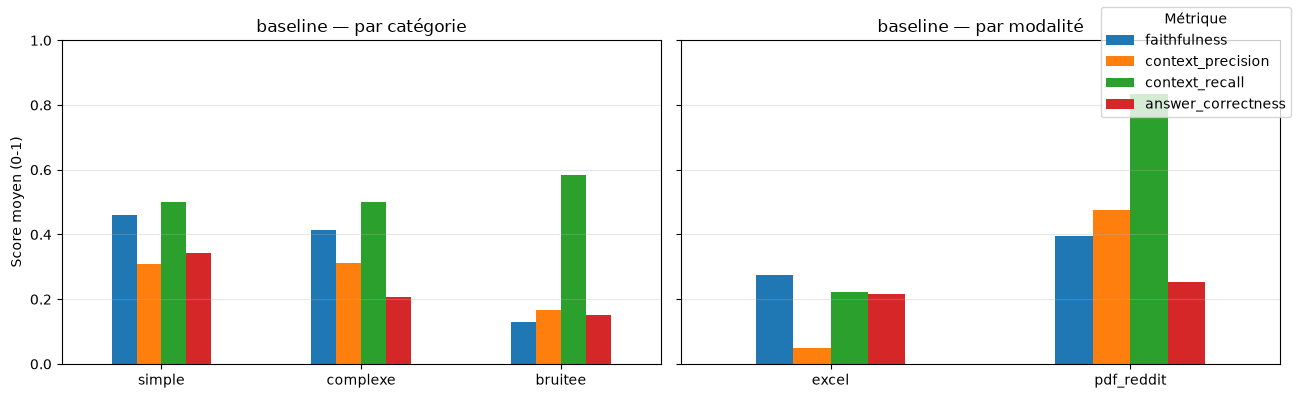

--- Comportement d'abstention ---
Axe non applicable : ce run précède la sortie structurée RAGAnswer.
--- Les 6 cas les plus faibles (faithfulness) ---

=== C1 (complexe / excel) ===
faithfulness=0.00  context_precision=0.00  context_recall=0.00  answer_correctness=0.13

Question : Quel joueur a le meilleur pourcentage de réussite à 3 points (3P%) parmi ceux ayant tenté plus de 300 tirs à 3 points cette saison ?

Réponse de référence : Zach LaVine, 44,6% sur 533 tentatives (3PA).

Réponse du système : D'après les données disponibles, voici l'analyse pour identifier le joueur avec le meilleur **3P%** parmi ceux ayant tenté **plus de 300 tirs à 3 points (3PA)** cette saison :

### **Top 5 des joueurs éligibles (3PA > 300) :**
*(Classés par 3P% décroissant)*

| **Joueur**               | **Équipe** | **3PA** | **3P%** | **PTS** | **FGM** | **FG%** |
|--------------------------|------------|---------|---------|---------|---------|---------|
| **Tyrese Haliburton**    | IND        | 320    

In [3]:
analyser("baseline")

## 2. Run `validation_pydantic` — avec la couche de validation Pydantic

Même traitement que la section 1, appliqué au run suivant.

In [4]:
analyser("validation_pydantic")

Run 'validation_pydantic' absent de results/ — rien à analyser pour l'instant.


## 3. Comparaison des runs

Seule section qui met les runs en regard. Vide tant qu'un seul run existe.

In [5]:
dispo = [r for r in RUNS if r in runs]

if len(dispo) < 2:
    print("Comparaison impossible : il faut au moins deux runs dans results/.")
else:
    premier, dernier = dispo[0], dispo[-1]
    df_all = pd.concat([runs[r].assign(run=r) for r in dispo], ignore_index=True)

    print(f"--- Scores globaux : {premier} vs {dernier} ---")
    globaux = df_all.groupby("run")[METRICS].mean().round(3).reindex(dispo)
    globaux.loc["delta"] = (globaux.loc[dernier] - globaux.loc[premier]).round(3)
    display(globaux)

    print("--- Par catégorie ---")
    par_cat = df_all.groupby(["run", "categorie"])[METRICS].mean().round(3)
    display(par_cat.reindex(pd.MultiIndex.from_product([dispo, ORDRE_CATEGORIES], names=["run", "categorie"])))

    # Un graphique par métrique : chaque groupe = une catégorie, chaque barre = un run
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
    for ax, metric in zip(axes.flat, METRICS):
        pivot = par_cat[metric].unstack("run").reindex(ORDRE_CATEGORIES)[dispo]
        pivot.plot(kind="bar", ax=ax, rot=0, legend=False)
        ax.set_title(metric)
        ax.set_xlabel("")
        ax.set_ylim(0, 1)
        ax.grid(axis="y", alpha=0.3)
    axes.flat[0].set_ylabel("Score moyen (0-1)")
    axes.flat[2].set_ylabel("Score moyen (0-1)")
    handles, noms = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, noms, title="Run", loc="upper right")
    fig.suptitle("Scores RAGAS par catégorie et par run")
    plt.tight_layout()
    plt.show()

    # Cas par cas : régressions en haut, progrès en bas
    print("--- Évolution du faithfulness, cas par cas ---")
    cas = (
        df_all.pivot(index="id", columns="run", values="faithfulness")[dispo]
        .reindex(runs[premier]["id"])  # ordre du testset : S1..S6, C1..C6, B1..B6
    )
    cas["delta"] = (cas[dernier] - cas[premier]).round(3)
    display(cas.sort_values("delta"))

Comparaison impossible : il faut au moins deux runs dans results/.


## 4. Conclusion

### Baseline — prototype avant amélioration

Scores globaux faibles (faithfulness 0.335, context_precision 0.262, context_recall 0.528, answer_correctness 0.234), pour deux raisons principales :

- **Retrieval défaillant sur l'Excel** : context_precision 0.050 et context_recall 0.222, contre 0.475 et 0.833 pour le PDF. Les 3 pires cas (C1, C2, B4 — faithfulness = 0.00) montrent le système inventer des joueurs fictifs (C1), de faux totaux pour les bons joueurs (C2), ou de fausses citations Reddit (B4) plutôt que de calculer correctement ou de s'abstenir.
- **Aucun mécanisme d'abstention** : la catégorie bruitée a le plus mauvais score de faithfulness (0.129) — le système répond avec assurance même quand il devrait signaler une absence, une ambiguïté ou une anomalie.

### Après la couche de validation Pydantic

_À compléter une fois le run `validation_pydantic` disponible._

Rappel méthodologique : ce run ne change **que** la couche de validation — structures d'entrée (chunks, embeddings, résultats de recherche) et de sortie (`RAGAnswer`, citations vérifiées, abstention possible). Le prompt et la température sont identiques à la baseline, précisément pour que l'écart mesuré soit attribuable à cette couche seule et pas à un prompt réécrit.

À noter : la validation d'entrée ne modifie pas ce que le modèle voit — elle contrôle des structures. On n'attend donc pas d'effet direct de sa part sur les métriques RAGAS ; son rôle est d'empêcher des corruptions silencieuses en amont.